In [1]:
# Importamos las librerías necesarias para la manipulación de datos, el modelado y la evaluación de modelos de clasificación.
# Estas incluyen pandas para el manejo de datos, scikit-learn para la creación y evaluación de modelos, y matplotlib para la visualización de resultados.

import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt



In [2]:
# Cargamos el conjunto de datos desde un archivo CSV utilizando pandas. Este conjunto de datos se utilizará para entrenar y evaluar los modelos de clasificación.

dataset = pd.read_csv(
    "../dataset_2sensors_xyz.csv"
)

dataset.head()
print(dataset.shape)


(138, 67)


In [3]:
# Separamos las características (X) de la variable objetivo (y).
# La variable objetivo es la columna "label", que contiene las etiquetas de clase para cada muestra. Las características son todas las demás columnas del conjunto de datos.
# Esto nos permitirá entrenar los modelos de clasificación utilizando las características para predecir las etiquetas de clase.

X = dataset.drop(
    "label",
    axis=1
)

y = dataset["label"]

In [4]:
# Dividimos el conjunto de datos en conjuntos de entrenamiento y prueba utilizando la función train_test_split de scikit-learn.
# El 80% de los datos se utilizará para entrenar los modelos, mientras que el 20% restante se utilizará para evaluar su rendimiento.
# La división se realiza de manera estratificada para asegurar que la proporción de clases en el conjunto de entrenamiento y prueba sea similar a la del conjunto de datos original.
# El parámetro random_state se establece en 42 para garantizar la reproducibilidad de los resultados.
# Esto nos permitirá evaluar el rendimiento de los modelos de clasificación en datos no vistos durante el entrenamiento.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [6]:
print(dataset.isna().sum())

rms_s0_x                   0
peak_s0_x                  0
crest_s0_x                 0
kurtosis_s0_x              0
std_s0_x                   0
                          ..
dominant_amp_s1_z          0
spectral_energy_s1_z       0
spectral_centroid_s1_z     0
spectral_bandwidth_s1_z    0
label                      0
Length: 67, dtype: int64


In [7]:
# Entrenamos un modelo de clasificación utilizando el algoritmo Random Forest.
# Este modelo se compone de múltiples árboles de decisión que trabajan juntos para mejorar la precisión de las predicciones.
# El número de árboles se establece en 100, lo que suele ser un buen punto de partida para obtener un rendimiento sólido sin incurrir en un tiempo de entrenamiento excesivo.
# El parámetro random_state se establece en 42 para garantizar la reproducibilidad de los resultados.
# Después de entrenar el modelo, realizamos predicciones en el conjunto de prueba para evaluar su rendimiento.
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

acc_rf = accuracy_score(
    y_test,
    pred_rf
)

print(acc_rf)

0.9285714285714286


In [8]:
# Entrenamos un modelo de clasificación utilizando el algoritmo Support Vector Machine (SVM).
# SVM es un algoritmo de clasificación que encuentra el hiperplano óptimo que separa las clases en el espacio de características.
# Después de entrenar el modelo, realizamos predicciones en el conjunto de prueba para evaluar su rendimiento.

svm = SVC()

svm.fit(
    X_train,
    y_train
)

pred_svm = svm.predict(
    X_test
)

acc_svm = accuracy_score(
    y_test,
    pred_svm
)

print(acc_svm)

0.6785714285714286


In [9]:
print("Random Forest")
print(classification_report(y_test, pred_rf))

Random Forest
               precision    recall  f1-score   support

       normal       1.00      1.00      1.00         7
unbalance_19g       1.00      0.86      0.92         7
unbalance_23g       1.00      0.86      0.92         7
unbalance_27g       0.78      1.00      0.88         7

     accuracy                           0.93        28
    macro avg       0.94      0.93      0.93        28
 weighted avg       0.94      0.93      0.93        28



In [10]:
print("SVM")
print(classification_report(y_test, pred_svm))

SVM
               precision    recall  f1-score   support

       normal       0.80      0.57      0.67         7
unbalance_19g       0.67      0.86      0.75         7
unbalance_23g       0.71      0.71      0.71         7
unbalance_27g       0.57      0.57      0.57         7

     accuracy                           0.68        28
    macro avg       0.69      0.68      0.68        28
 weighted avg       0.69      0.68      0.68        28



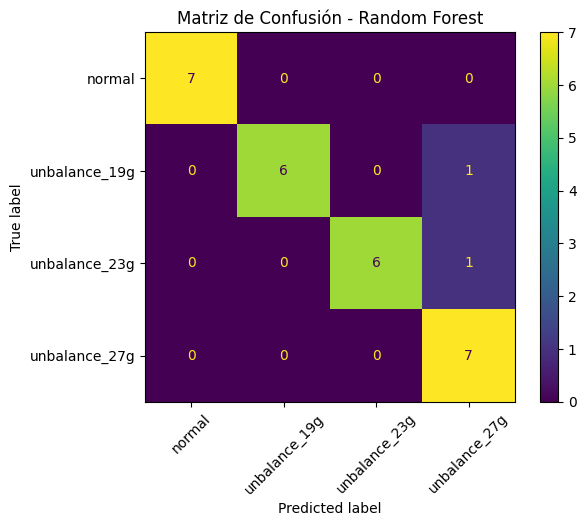

In [11]:
# Generamos un informe de clasificación utilizando la función classification_report de scikit-learn, que proporciona métricas detalladas como precisión, recall y F1-score para cada clase.
# Esto nos permitirá evaluar el rendimiento del modelo en cada clase individualmente y entender mejor dónde el modelo puede estar cometiendo errores.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_rf,
    xticks_rotation=45
)

plt.title("Matriz de Confusión - Random Forest")

plt.show()

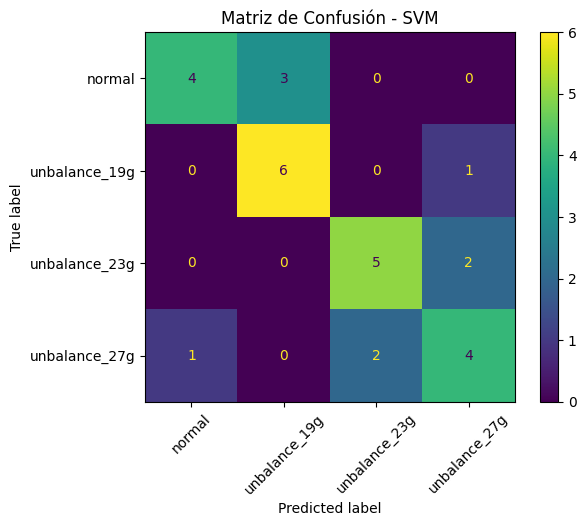

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_svm,
    xticks_rotation=45
)

plt.title("Matriz de Confusión - SVM")

plt.show()

In [13]:
print("Accuracy")
results = pd.DataFrame({
    "Modelo":[
        "Random Forest",
        "SVM"
    ],
    "Accuracy":[
        acc_rf,
        acc_svm
    ]
})

results

Accuracy


,Modelo,Accuracy
0,Random Forest,0.928571
1,SVM,0.678571


### Se desarrolló un sistema de clasificación de condiciones de operación utilizando señales de vibración. Las señales fueron segmentadas en ventanas y se extrajeron características estadísticas y espectrales. Se entrenaron modelos Random Forest y SVM, obteniéndose una clasificación multiclase de las condiciones Normal, Unbalance 19 g, Unbalance 23 g y Unbalance 27 g. El modelo con mayor accuracy fue seleccionado como modelo final.

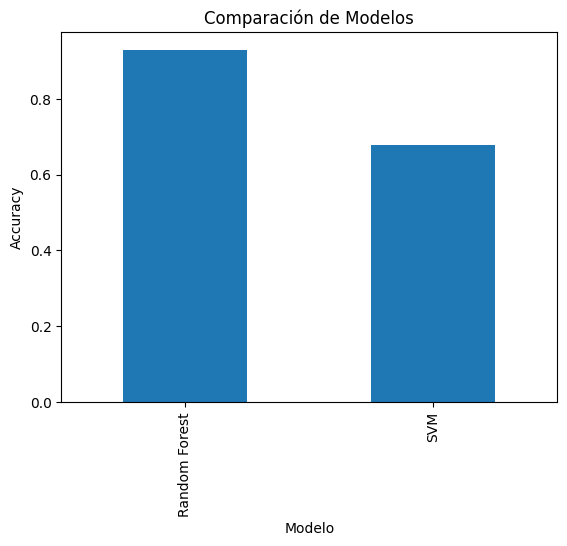

In [14]:
results = pd.DataFrame({
    "Modelo": ["Random Forest", "SVM"],
    "Accuracy": [acc_rf, acc_svm]
})

results.plot(
    x="Modelo",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Comparación de Modelos")

plt.show()

In [15]:
# Cross Validation - Random Forest
# La validación cruzada es una técnica que se utiliza para evaluar el rendimiento de un modelo de clasificación de manera más robusta.
# En lugar de entrenar y evaluar el modelo en un solo conjunto de entrenamiento y prueba, la validación cruzada divide el conjunto de datos en múltiples subconjuntos (o "folds") y
# realiza múltiples iteraciones de entrenamiento y evaluación.
# En cada iteración, el modelo se entrena en un subconjunto de los datos (por ejemplo, 4 de los 5 folds) y se evalúa en el fold restante.
# Este proceso se repite hasta que cada fold haya sido utilizado como conjunto de prueba.

scores_rf = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("RANDOM FOREST")

print("Scores:")
print(scores_rf)

print()

print("Accuracy promedio:")
print(scores_rf.mean())

print()

print("Desviación estándar:")
print(scores_rf.std())

RANDOM FOREST
Scores:
[0.53571429 0.85714286 0.92857143 0.81481481 0.7037037 ]

Accuracy promedio:
0.767989417989418

Desviación estándar:
0.1371217894850833


In [16]:
# Cross Validation - SVM

scores_svm = cross_val_score(
    SVC(),
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("SVM")

print("Scores:")
print(scores_svm)

print()

print("Accuracy promedio:")
print(scores_svm.mean())

print()

print("Desviación estándar:")
print(scores_svm.std())

SVM
Scores:
[0.46428571 0.35714286 0.53571429 0.40740741 0.51851852]

Accuracy promedio:
0.45661375661375664

Desviación estándar:
0.0670278700672432


In [17]:
print("Accuracy CV")
cv_results = pd.DataFrame({

    "Modelo":[
        "Random Forest",
        "SVM"
    ],

    "Accuracy CV":[
        scores_rf.mean(),
        scores_svm.mean()
    ]

})

cv_results

Accuracy CV


,Modelo,Accuracy CV
0,Random Forest,0.767989
1,SVM,0.456614


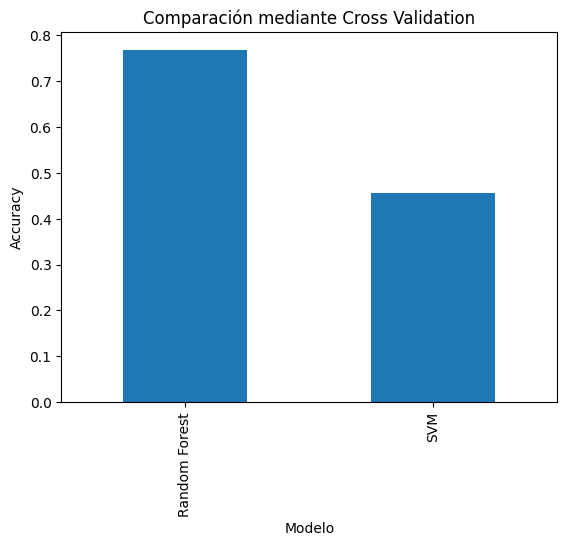

In [18]:
cv_results.plot(
    x="Modelo",
    y="Accuracy CV",
    kind="bar",
    legend=False
)

plt.ylabel("Accuracy")

plt.title(
    "Comparación mediante Cross Validation"
)

plt.show()

In [19]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

In [20]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [21]:
grid_rf.fit(
    X,
    y
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [22]:
print("Mejor Accuracy CV:")
print(grid_rf.best_score_)

print("\nMejores parámetros:")
print(grid_rf.best_params_)

Mejor Accuracy CV:
0.767989417989418

Mejores parámetros:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


In [23]:
results_grid = pd.DataFrame(
    grid_rf.cv_results_
)

In [24]:
results_grid = results_grid[
    [
        "mean_test_score",
        "std_test_score",
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split"
    ]
]

In [25]:
results_grid.sort_values(
    by="mean_test_score",
    ascending=False
).head(10)

,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_min_samples_split
1,0.767989,0.100643,200,5,2
9,0.767989,0.137122,100,10,2
11,0.767989,0.135249,300,10,2
5,0.767989,0.100643,300,5,5
35,0.767989,0.121329,300,None,10
31,0.767989,0.080978,200,None,5
34,0.767989,0.100643,200,None,10
8,0.767989,0.100643,300,5,10
16,0.767989,0.100643,200,10,10
17,0.767989,0.121329,300,10,10


In [26]:
results_grid.to_csv(
    "../results/gridsearch_rf.csv",
    index=False
)